**1D-CNN on Tabular**

In [35]:
!pip install pydot graphviz

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Dropout, Flatten, Dense, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential

In [2]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [3]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [4]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [5]:
numeric_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='median')),  # fill missing values
    ('scale',  StandardScaler())                   # standardize features
])

In [6]:

cat_pipeline_simple = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),  # fill missing with "MISSING"
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # one-hot encode
])


In [13]:
preprocessor_simple = ColumnTransformer([
    ('num', numeric_pipeline_simple, num_columns),
    ('cat', cat_pipeline_simple,  multi_class_columns + binary_columns),
], remainder='drop')


In [14]:
X_train_enc_simple = preprocessor_simple.fit_transform(X_train)
X_val_enc_simple   = preprocessor_simple.transform(X_val)

In [15]:
# 2) Define your CNN build‐fn
def build_cnn_simple(input_dim, **kwargs):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),              # treat features as a 1D signal
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

In [17]:
# 3) Wrap in SciKeras classifier
from scikeras.wrappers import KerasClassifier
input_dim_simple = X_train_enc_simple.shape[1]
cnn_simple = KerasClassifier(
    build_fn    = build_cnn_simple,
    input_dim   = input_dim_simple,
    epochs      = 20,
    batch_size  = 64,
    validation_split = 0.2,
    verbose     = 1
)

In [18]:
# 4) Full sklearn Pipeline (so you don’t need to manually call .transform)
pipe_cnn_simple = Pipeline([
    ('preproc', preprocessor_simple),
    ('clf',     cnn_simple)
])

In [19]:
# 5) Train
pipe_cnn_simple.fit(X_train, y_train)

Epoch 1/20


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
2025-04-27 07:26:08.028739: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


3225/3225 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6051 - loss: 0.7850 - val_accuracy: 0.6298 - val_loss: 0.7586
Epoch 2/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6321 - loss: 0.7492 - val_accuracy: 0.6520 - val_loss: 0.7364
Epoch 3/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6495 - loss: 0.7314 - val_accuracy: 0.6548 - val_loss: 0.7220
Epoch 4/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6567 - loss: 0.7213 - val_accuracy: 0.6592 - val_loss: 0.7152
Epoch 5/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6601 - loss: 0.7147 - val_accuracy: 0.6595 - val_loss: 0.7161
Epoch 6/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6601 - loss: 0.7117 - val_accuracy: 0.6597 - val_loss: 0.7145
Epoch 7/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6643 - loss: 0.7063 - val_accuracy: 0.6644 - val_loss: 0.7064
Epoch 8/20
3225/3225 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6660 - loss: 0.7036 - val_accura

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_percentage',
                                                   'height_percentage',
                                                   'has_superstructure_adobe_mud',
                                                   'has_superstructure_mud_mortar_s...
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf',
                 KerasClassifier(batch_size=64, build_fn=<function build_cnn_simple at 0x14bdadb587c0>, epochs=20, input_dim=69, validation_split=0.2))])

In [22]:
# 6) Evaluate on validation set
y_pred = pipe_cnn_simple.predict(X_val)
# 5) Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy on validation set: 0.6770233985423859

Classification Report:
               precision    recall  f1-score   support

           1       0.65      0.46      0.54       246
           2       0.69      0.79      0.74      1490
           3       0.65      0.55      0.59       871

    accuracy                           0.68      2607
   macro avg       0.66      0.60      0.62      2607
weighted avg       0.67      0.68      0.67      2607



In [33]:
# Import the plotting helper
from tensorflow.keras.utils import plot_model
from IPython.display         import Image

# Create an instance with your input_dim
model = build_cnn_simple(input_dim_simple)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 69, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 67, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       137,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,603 (537.51 KB)

 Trainable params: 137,603 (537.51 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
df_test = pd.read_csv('test_values.csv')

In [25]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [26]:
X_test  = df_test

In [28]:
preds = pipe_cnn_simple.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('CNN_simple_submission.csv', index=False)

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


*** Preprocessed CNN****

In [37]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

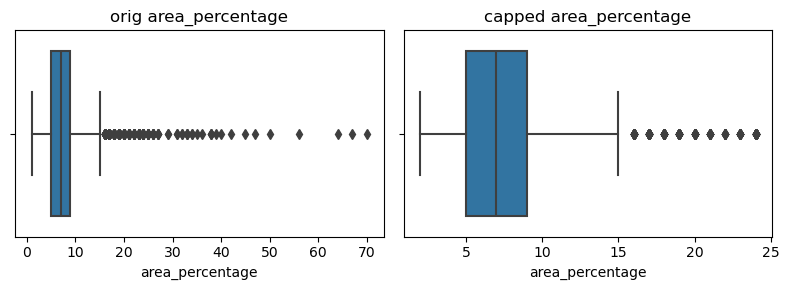

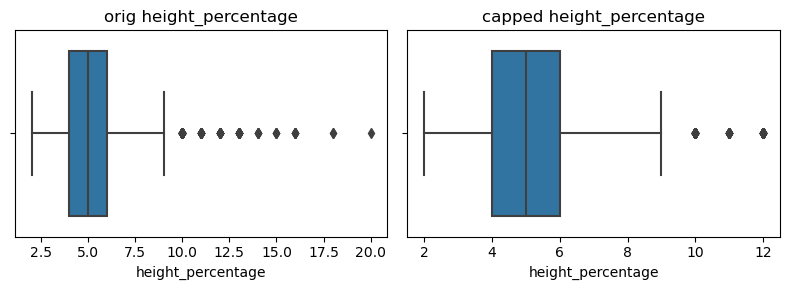

In [38]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [41]:
from sklearn.base import BaseEstimator, TransformerMixin
# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [57]:
from sklearn.preprocessing import PowerTransformer, RobustScaler
# 2) Numeric pipeline
numeric_pipeline_complex = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [51]:
# 3) Binary-cat: constant “MISSING” → ordinal (0/1)
binary_pipeline_complex = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ord',    OrdinalEncoder()),
])

In [54]:
# 4) Multi-cat: constant “MISSING” → one‐hot
multi_pipeline_complex = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [58]:
# 5) ColumnTransformer
preprocessor_complex = ColumnTransformer([
    ('num',   numeric_pipeline_complex,   num_columns),
    ('bin',   binary_pipeline_complex,    binary_columns),
    ('multi', multi_pipeline_complex,     multi_class_columns),
], remainder='drop')

In [59]:
# 6) Fit & transform
X_train_enc = preprocessor_complex.fit_transform(X_train)
X_val_enc   = preprocessor_complex.transform(X_val)


In [60]:
# # 5) Pipeline factory
# def get_pipeline(model):
#     """
#     Returns a full Pipeline that:
#      - applies preprocessor to DataFrame
#      - then fits the model
#     """
#     return Pipeline([
#         ('preprocessor', preprocessor),
#         ('clf',        model)
#     ])

In [61]:
# # 7) Quick Stratified 3-fold CV to compare
# cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# scoring = {
#     'acc':  'accuracy',
#     'f1':   'f1',       # or 'f1_weighted', depending on your class balance
#     'prec': 'precision',
#     'rec':  'recall'
# }

In [62]:
# — CELL 2: Complex 1D-CNN Model —  
from scikeras.wrappers      import KerasClassifier
from tensorflow.keras       import Sequential, Input
from tensorflow.keras.layers import Reshape, Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.pipeline       import Pipeline
from sklearn.metrics        import classification_report

# 1) Build-fn with a bit more depth
def build_cnn_complex(input_dim, **kwargs):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),
        Conv1D(64, kernel_size=3, activation='relu'),
        Conv1D(32, kernel_size=3, activation='relu'),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(3,   activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

# 2) Wrap in SciKeras
input_dim_complex = X_train_enc.shape[1]
cnn_complex = KerasClassifier(
    build_fn        = build_cnn_complex,
    input_dim       = input_dim_complex,
    epochs          = 30,
    batch_size      = 128,
    validation_split= 0.2,
    callbacks       = [
        EarlyStopping('val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau('val_loss', factor=0.3, patience=3)
    ],
    verbose         = 1
)

In [63]:
# 3) Pipeline: complex preprocess + CNN
pipe_cnn_complex = Pipeline([
    ('preproc', preprocessor_complex),
    ('clf',     cnn_complex)
])

# 4) Train & evaluate
pipe_cnn_complex.fit(X_train, y_train)

Epoch 1/30


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


1613/1613 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6026 - loss: 0.7875 - val_accuracy: 0.6494 - val_loss: 0.7372 - learning_rate: 0.0010
Epoch 2/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6538 - loss: 0.7256 - val_accuracy: 0.6675 - val_loss: 0.7050 - learning_rate: 0.0010
Epoch 3/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6682 - loss: 0.7032 - val_accuracy: 0.6743 - val_loss: 0.6949 - learning_rate: 0.0010
Epoch 4/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6757 - loss: 0.6904 - val_accuracy: 0.6787 - val_loss: 0.6864 - learning_rate: 0.0010
Epoch 5/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6819 - loss: 0.6784 - val_accuracy: 0.6810 - val_loss: 0.6836 - learning_rate: 0.0010
Epoch 6/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6868 - loss: 0.6716 - val_accuracy: 0.6817 - val_loss: 0.6826 - learning_rate: 0.0010
Epoch 7/30
1613/1613 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6918 - loss:

Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('cap',
                                                                   OutlierCapper(cols=['area_percentage',
                                                                                       'height_percentage'])),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'geo_level_2_id',
                                                   'geo_level_3_id',
                                                   'count_floors_pre_eq', 'age',
                                                   'area_...
                                                   'plan_configuration',
                                                   'legal_ownership_status'])])),
                ('clf',
                 KerasClassifier(batch_size=128, build_fn=<function build_cnn_complex at 0x14bd9d180900>, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x14bd9d94ded0>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x14bd9d306650>], epochs=30, input_dim=69, validation_split=0.2))])

In [65]:
y_val_pred = pipe_cnn_complex.predict(X_val)
print(classification_report(y_val, y_val_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           1       0.61      0.49      0.54       246
           2       0.71      0.81      0.75      1490
           3       0.69      0.56      0.62       871

    accuracy                           0.69      2607
   macro avg       0.67      0.62      0.64      2607
weighted avg       0.69      0.69      0.69      2607



In [66]:
# 4) Predict on validation set
y_pred =pipe_cnn_complex.predict(X_val)

# 5) Evaluate
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy on validation set:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy on validation set: 0.694668200997315

Classification Report:
               precision    recall  f1-score   support

           1       0.61      0.49      0.54       246
           2       0.71      0.81      0.75      1490
           3       0.69      0.56      0.62       871

    accuracy                           0.69      2607
   macro avg       0.67      0.62      0.64      2607
weighted avg       0.69      0.69      0.69      2607



In [67]:
preds = pipe_cnn_complex.predict(X_test)
# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,          # make sure you have 'ids' variable defined
    'damage_grade': preds
}).to_csv('ANN_complex_submission.csv', index=False)

679/679 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Hyperparameter Tuning**

In [70]:
import keras_tuner as kt
from kerastuner import HyperModel, RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

In [71]:
X_train_enc2 = preprocessor_complex.fit_transform(X_train)
# now define input_dim2 from its second dimension:
input_dim2 = X_train_enc2.shape[1]

In [72]:
def build_cnn_tuned(input_dim,
                    filters      = 32,
                    kernel_size  = 3,
                    dense_units  = 64,
                    **kwargs):
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),
        Conv1D(filters, kernel_size, activation='relu'),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dense(3, activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

cnn_tuned = KerasClassifier(
    build_fn  = build_cnn_tuned,
    input_dim = input_dim2,   # from complex case
    validation_split = 0.2,
    verbose   = 0
)

pipe_cnn_tuned = Pipeline([
    ('preproc', preprocessor_complex),
    ('clf',     cnn_tuned)
])

In [74]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    # forwarded into build_cnn_tuned(...)
    'clf__model__filters':     [16, 32, 64],
    'clf__model__kernel_size': [2, 3, 5],
    'clf__model__dense_units': [32, 64, 128],

    # wrapper params
    'clf__batch_size':  [64, 128],
    'clf__epochs':      [20, 30],
}

search = RandomizedSearchCV(
    pipe_cnn_tuned,
    param_distributions = param_dist,
    n_iter    = 10,
    cv        = 3,
    scoring   = 'f1_macro',
    refit     = True,
    verbose   = 2,
    n_jobs    = 1
)

search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


[CV] END clf__batch_size=64, clf__epochs=30, clf__model__dense_units=32, clf__model__filters=32, clf__model__kernel_size=5; total time= 2.7min


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


[CV] END clf__batch_size=64, clf__epochs=30, clf__model__dense_units=32, clf__model__filters=32, clf__model__kernel_size=5; total time= 2.7min


...

[CV] END clf__batch_size=128, clf__epochs=30, clf__model__dense_units=128, clf__model__filters=64, clf__model__kernel_size=5; total time= 3.0min


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


[CV] END clf__batch_size=128, clf__epochs=30, clf__model__dense_units=128, clf__model__filters=64, clf__model__kernel_size=5; total time= 3.0min


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preproc',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('cap',
                                                                                                OutlierCapper(cols=['area_percentage',
                                                                                                                    'height_percentage'])),
                                                                                               ('power',
                                                                                                PowerTransformer()),
                                                                                               ('scale',
                                                                                                RobustScaler())]),
                                                                               ['building_id',
                                                                                'geo_level_1_id',
                                                                                'geo_level_2_id',
                                                                                'geo_level_3_id',...
                                                                                'legal_ownership_status'])])),
                                             ('clf',
                                              KerasClassifier(build_fn=<function build_cnn_tuned at 0x14bd9d157380>, input_dim=69, validation_split=0.2, verbose=0))]),
                   n_jobs=1,
                   param_distributions={'clf__batch_size': [64, 128],
                                        'clf__epochs': [20, 30],
                                        'clf__model__dense_units': [32, 64,
                                                                    128],
                                        'clf__model__filters': [16, 32, 64],
                                        'clf__model__kernel_size': [2, 3, 5]},
                   scoring='f1_macro', verbose=2)

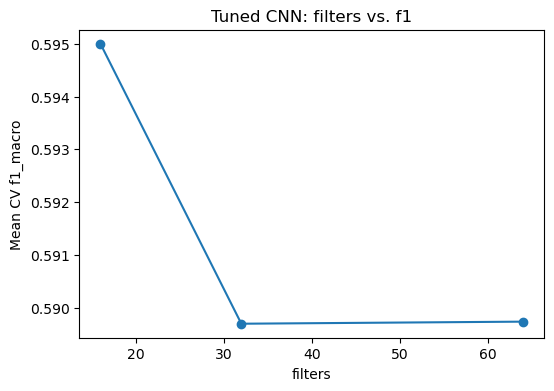

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(search.cv_results_)

# Example: Mean test F1 vs. number of filters
# we stored filters under 'param_clf__model__filters'
grouped = results.groupby('param_clf__model__filters')['mean_test_score'].mean()

plt.figure(figsize=(6,4))
plt.plot(grouped.index.astype(int), grouped.values, marker='o')
plt.xlabel('filters')
plt.ylabel('Mean CV f1_macro')
plt.title('Tuned CNN: filters vs. f1')
plt.show()


In [81]:
print("Best params:", search.best_params_)
print("Best CV F1 score:", search.best_score_)

Best params: {'clf__model__kernel_size': 5, 'clf__model__filters': 32, 'clf__model__dense_units': 128, 'clf__epochs': 30, 'clf__batch_size': 64}
Best CV F1 score: 0.6019598445077358


In [78]:
# 2) Grab the final, refit pipeline
best_cnn_pipe = search.best_estimator_

# 3) (Optional) Retrain explicitly on full data—though best_estimator_ is already fitted:
best_cnn_pipe.fit(X_train, y_train)

# 4) Generate predictions on your test set
preds = best_cnn_pipe.predict(X_test)

# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,
    'damage_grade': preds
}).to_csv('CNN_tuned_submission.csv', index=False)


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
